In [27]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

In [28]:
def parse_experiment_log_files(barrier_name: str, num_robots: int) -> tuple[float, float, float]:
    """
    Parse the mean completion time, standard deviation, and completion percentage for a given barrier and number
    of robots
    """
    log_files = [f"../random_goals/{barrier_name}/{i}/{num_robots}.txt" for i in range(10)]
    all_times = []
    completions = 0
    for log_file in log_files:
        with open(log_file, "r") as f:
            total_completion_time = np.nan
            for line in f.readlines():
                if "Experiment completed successfully" in line:
                    parts = line.split(" ")
                    total_completion_time = float(parts[-2])
            if total_completion_time is not np.nan:
                completions += 1
                all_times.append(total_completion_time)
    if completions == 0:
        return np.nan, np.nan, 0.0
    mean_time = np.mean(all_times)
    std_time = np.std(all_times)
    return mean_time, std_time, completions / 10.0

def parse_experiment_data(barrier_name: str, num_robots: int) -> tuple[float, float, list[float]]:
    """
    Parses the experiment data for a given barrier and number of robots.

    Args:
        barrier_name (str): The name of the barrier.
        num_robots (int): The number of robots.

    Returns:
        tuple: A tuple containing the mean time, standard deviation, and a list of average times per robot.
    """
    log_files = [f"../random_goals/{barrier_name}/{i}/{num_robots}.txt" for i in range(10)]
    all_times = []
    for log_file in log_files:
        with open(log_file, "r") as f:
            total_completion_time = np.nan
            for line in f.readlines():
                if "Experiment completed successfully" in line:
                    parts = line.split(" ")
                    total_completion_time = float(parts[-2])
            all_times.append(total_completion_time)
    mean_time = np.nanmean(all_times)
    std_time = np.nanstd(all_times)
    total_times_per_robot = [np.nan for _ in range(num_robots)]
    total_completions_per_robot = [0 for _ in range(num_robots)]
    completion_files = [f"../random_goals/{barrier_name}/completion_times/{i}/{num_robots}.npy" for i in range(5)]
    for completion_file in completion_files:
        completion_times = np.load(completion_file)
        for goal in range(1):
            for robot in range(num_robots):
                if not np.isnan(completion_times[goal, robot]):
                    total_times_per_robot[robot] += completion_times[goal, robot]
                    total_completions_per_robot[robot] += 1
    average_times_per_robot = [total_times_per_robot[i] / total_completions_per_robot[i] if total_completions_per_robot[i] > 0 else np.nan for i in range(num_robots)]
    return mean_time, std_time, average_times_per_robot

In [29]:
parse_experiment_data("progress", 5)

(np.float64(14.883000000000001),
 np.float64(2.0159863590808347),
 [np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan)])

In [32]:
BARRIER_NAMES = ["progress", "decentralized", "centralized"]
# NUM_ROBOTS = [4, 8, 11, 16, 20]
NUM_ROBOTS = [i for i in range(1, 21)]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

barrier_data = {
    barrier_name: {
        i: parse_experiment_data(barrier_name, i) for i in NUM_ROBOTS
    }
    for barrier_name in BARRIER_NAMES
}
print(barrier_data)

{'progress': {1: (np.float64(10.678999999999998), np.float64(3.8279928160852132), [np.float64(nan)]), 2: (np.float64(11.648000000000001), np.float64(3.0795122990499646), [np.float64(nan), np.float64(nan)]), 3: (np.float64(13.587), np.float64(2.919013703290891), [np.float64(nan), np.float64(nan), np.float64(nan)]), 4: (np.float64(14.896), np.float64(2.5088172512161986), [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]), 5: (np.float64(14.883000000000001), np.float64(2.0159863590808347), [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]), 6: (np.float64(15.443999999999999), np.float64(2.306409330539573), [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]), 7: (np.float64(16.344), np.float64(2.593427076283426), [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]), 8: (np.float64(18.124000000000002), np.float64(2.329

In [35]:
def get_df() -> pl.DataFrame:
    df = pl.DataFrame({}, schema={
        "N": pl.Int8,
        "Centralized Time": pl.Float64,
        "Centralized Std": pl.Float64,
        "Decentralized Time": pl.Float64,
        "Decentralized Std": pl.Float64,
        "Progress Time": pl.Float64,
        "Progress Std": pl.Float64,
        "Centralized Percent": pl.Float64,
        "Decentralized Percent": pl.Float64,
        "Progress Percent": pl.Float64,
    })
    for num_robots in NUM_ROBOTS:
        centralized_mean, centralized_std, centralized_percent = parse_experiment_log_files("centralized", num_robots)
        decentralized_mean, decentralized_std, decentralized_percent = parse_experiment_log_files("decentralized", num_robots)
        progress_mean, progress_std, progress_percent = parse_experiment_log_files("progress", num_robots)
        df = df.vstack(pl.DataFrame({
            "N": [num_robots],
            "Centralized Time": [centralized_mean],
            "Centralized Std": [centralized_std],
            "Decentralized Time": [decentralized_mean],
            "Decentralized Std": [decentralized_std],
            "Progress Time": [progress_mean],
            "Progress Std": [progress_std],
            "Centralized Percent": [centralized_percent],
            "Decentralized Percent": [decentralized_percent],
            "Progress Percent": [progress_percent],
        },
        schema={
            "N": pl.Int8,
            "Centralized Time": pl.Float64,
            "Centralized Std": pl.Float64,
            "Decentralized Time": pl.Float64,
            "Decentralized Std": pl.Float64,
            "Progress Time": pl.Float64,
            "Progress Std": pl.Float64,
            "Centralized Percent": pl.Float64,
            "Decentralized Percent": pl.Float64,
            "Progress Percent": pl.Float64,
        }
    ))
    return df

df = get_df()
df.show(limit=20)

N,Centralized Time,Centralized Std,Decentralized Time,Decentralized Std,Progress Time,Progress Std,Centralized Percent,Decentralized Percent,Progress Percent
i8,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,10.679,3.827993,10.679,3.827993,10.679,3.827993,1.0,1.0,1.0
2,11.529,2.975028,11.671,3.119155,11.648,3.079512,1.0,1.0,1.0
3,13.371,2.675804,13.428,2.90071,13.587,2.919014,1.0,1.0,1.0
4,14.321,2.024818,14.434,2.119062,14.896,2.508817,1.0,1.0,1.0
5,14.384,2.032231,14.636,2.136142,14.883,2.015986,1.0,1.0,1.0
6,14.84,2.339205,14.956,2.292397,15.444,2.306409,1.0,1.0,1.0
7,15.459,2.459542,15.468,2.391016,16.344,2.593427,1.0,1.0,1.0
8,15.912,1.731703,15.962,1.683002,18.124,2.32916,1.0,1.0,1.0
9,16.243,1.788251,16.372,1.787052,20.14,4.144794,1.0,1.0,1.0


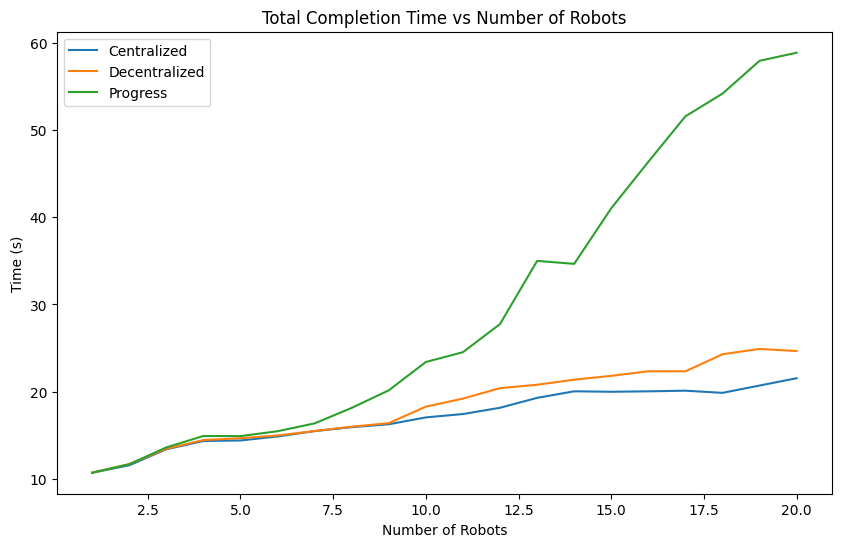

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(df["N"], df["Centralized Time"], label="Centralized", color=COLORS[0])
plt.plot(df["N"], df["Decentralized Time"], label="Decentralized", color=COLORS[1])
plt.plot(df["N"], df["Progress Time"], label="Progress", color=COLORS[2])

plt.xlabel("Number of Robots")
plt.ylabel("Time (s)")
plt.title("Total Completion Time vs Number of Robots")
plt.legend()
plt.show()